# Imports

## Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from torch.utils.tensorboard import SummaryWriter 
import json
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from sklearn.manifold import spectral_embedding
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import rbf_kernel

## Import Dataset Classes

In [2]:
from dataset_classes import ISO_NE, ISO_NE_Small, AT, BD_Dataset, NCENT_Dataset, SH_Dataset, PL_Dataset, TN_Dataset

## Import Models

In [ ]:
from models_with_temporal_graph import TR_GNN_Attention, TR_GNN_GlobalLocal, TR_GNN_GraphGRU, TR_GNN_Linear, TR_GNN_MultiScale

## Import Training and Testing Loops

In [4]:
from helper_functions_trial import train_model, test_model

# Main Function

## AT

### Linear

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = TR_GNN_Linear(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_TR_GNN_Linear"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

### Attention

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = TR_GNN_Attention(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_TR_GNN_Attention"
    
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

### GlobalLocal

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = TR_GNN_GlobalLocal(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_TR_GNN_GlobalLocal"
    log_dir = f"Final_Metrics/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

### MultiScale

In [ ]:
# Main Function
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = AT(
        csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    # --- 1. Define splits based on RAW data length ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)
    
    print(f"Raw data length: {total_len}")
    print(f"Scaler 'train_size' (raw rows): {train_split_idx}")
    print(f"Scaler 'val_end' (raw rows): {val_split_idx}")

    # --- 2. Fit scaler only on the raw TRAIN subset ---
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))

    # --- 3. Apply same scaler to all data ---
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler  # keep for later inverse-transform

    # --- 4. Calculate SAMPLE indices to align with RAW splits ---
    
    # A sample 'idx' uses an input window from [idx] to [idx + T_in].
    # To prevent data leakage, the *input window* of a training sample
    # must not see any validation data. Validation data starts at `train_split_idx`.
    
    # The last training sample's input window must end at or before `train_split_idx - 1`.
    # idx + T_in - 1 <= train_split_idx - 1  =>  idx <= train_split_idx - T_in
    
    # The `range(start, end)` function's 'end' is exclusive, so this works perfectly.
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    
    # Get the total number of *valid* samples
    effective_len = len(dataset)
    
    # Ensure our calculated indices don't exceed the total number of samples
    train_end = min(train_end, effective_len)
    val_end = min(val_end, effective_len)

    train_idx = range(0, train_end)
    val_idx = range(train_end, val_end)
    test_idx = range(val_end, effective_len)

    print(f"Total valid samples: {effective_len}")
    print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
    
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    test_subset = Subset(dataset, test_idx)

    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
    
    # --- DataLoaders ---
    train_loader = DataLoader(train_subset, batch_size=hparams["batch_size"], shuffle=False)
    val_loader = DataLoader(val_subset, batch_size=hparams["batch_size"], shuffle=False)
    test_loader = DataLoader(test_subset, batch_size=hparams["batch_size"], shuffle=False)
    print(f"\n🚚 DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
    
    # --- Model ---
    model = TR_GNN_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
    ).to(device)
    
    # Run name
    run = "AT_TR_GNN_MultiScale_Temporal_Graph_Learning"
    
    log_dir = f"CSE498R_Supervisor_Fixes/{run}"  # Define log directory for TensorBoard
    writer = SummaryWriter(log_dir)
    
    # Log hyperparameters as text (avoid add_hparams which requires a metric_dict)
    writer.add_text("hparams", json.dumps(hparams, indent=2))
    
    print("\n🚀 Training GLFN-TC model on AT dataset...")
    model = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hparams["epochs"],
        lr=hparams["lr"],
        device=device,
        scheduler_patience=hparams["scheduler_patience"],
        writer=writer,
        weight_decay=hparams["weight_decay"],
        save_path=f"Final_Run/{run}_best_model.pth"
    )

    print("\n🧪 Testing model performance...\n")
    preds, trues = test_model(
        dataset=dataset,
        model=model, test_loader=test_loader,
        device=device,
        writer=writer
    )
    
    writer.close()

if __name__ == "__main__":
    main()

# ReScale

Using device: cuda
Loaded dataset with 18 features (target=demand), total rows=52440
Fitting scaler on training data...
Test samples: 10248
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 161/161 [00:01<00:00, 88.00it/s] 



Inverse transforming data...

      REAL-WORLD METRICS (Original Scale)
MSE:  210363.5957
RMSE: 458.6541
MAE:  315.5837
R²:   0.9094

Plot saved to MultiScale_Forecast_Plot.png


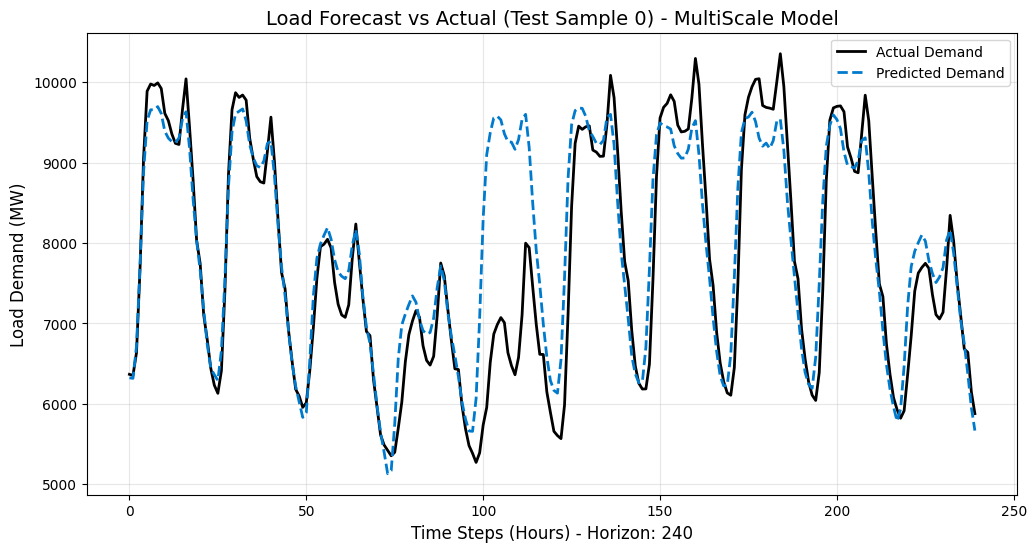

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    """
    Manually inverse transforms the target variable using the scaler's 
    stored mean and scale (std) for the specific target column.
    """
    # Get the specific mean and std for the target column
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    
    # Apply inverse transformation: x_original = x_scaled * std + mean
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    val_split_idx = int(0.8 * total_len)

    # --- 2. Re-fit the Scaler ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    
    # Apply scaler to dataset
    dataset.apply_scaler(scaler)
    
    # --- CRITICAL FIX: Manually store the scaler in the dataset object ---
    dataset.scaler = scaler 
    
    # Define Test Indices
    train_end = train_split_idx - dataset.T_in
    val_end = val_split_idx - dataset.T_in
    effective_len = len(dataset)
    val_end = min(val_end, effective_len) 
    
    test_idx = range(val_end, effective_len)
    test_subset = Subset(dataset, test_idx)
    
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    print(f"Test samples: {len(test_idx)}")

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = TR_GNN_MultiScale(
        N=hparams["N"],
        T_in=hparams["T_in"],
        T_out=hparams["T_out"],
        d=hparams["d"],
        hidden_dim=hparams["hidden_dim"],
        GCN_Layer=hparams["GCN_Layer"],
        dropout_gcn=hparams["dropout_gcn"],
        dropout_temporal=hparams["dropout_temporal"],
        dropout_forecast=hparams["dropout_forecast"]
    ).to(device)

    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Run Inference ---
    model.eval()
    preds_list = []
    trues_list = []

    print("Running inference...")
    with torch.no_grad():
        for X, Y in tqdm(test_loader):
            X = X.to(device)
            Y = Y.to(device)
            
            # The MultiScale model returns (prediction, adjacency)
            out, _ = model(X) 
            
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    # Concatenate all batches
    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)

    # --- 5. Inverse Transform ---
    print("\nInverse transforming data...")
    # Now dataset.scaler exists because we assigned it in Step 2
    preds_orig, trues_orig = inverse_transform_targets(
        preds_scaled, 
        trues_scaled, 
        dataset.scaler, 
        target_idx=dataset.target_idx 
    )

    # --- 6. Calculate Metrics (Original Scale) ---
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)

    print("\n" + "="*40)
    print("      REAL-WORLD METRICS (Original Scale)")
    print("="*40)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print("="*40)

    # --- 7. Plotting ---
    sample_idx = 0 
    
    plt.figure(figsize=(12, 6))
    plt.plot(trues_orig[sample_idx], label='Actual Demand', color='black', linewidth=2)
    plt.plot(preds_orig[sample_idx], label='Predicted Demand', color='#007acc', linestyle='--', linewidth=2)
    
    plt.title(f"Load Forecast vs Actual (Test Sample {sample_idx}) - MultiScale Model", fontsize=14)
    plt.xlabel(f"Time Steps (Hours) - Horizon: {hparams['T_out']}", fontsize=12)
    plt.ylabel("Load Demand (MW)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_img_path = "MultiScale_Forecast_Plot.png"
    plt.savefig(save_img_path, dpi=300)
    print(f"\nPlot saved to {save_img_path}")
    plt.show()

if __name__ == "__main__":
    main()

Using device: cuda
Loaded dataset with 18 features (target=demand), total rows=52440
Fitting scaler on training data...

🎲 Randomly selecting 64 samples from the unseen data pool...
   Pool size: 20664 potential windows
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 1/1 [00:00<00:00, 27.78it/s]


      REAL-WORLD METRICS (Original Scale)
MSE:  178811.8323
RMSE: 422.8615
MAE:  280.9013
MAPE: 3.5932%
R²:   0.9166



Plot saved to Random_Forecast_Idx_39049.png


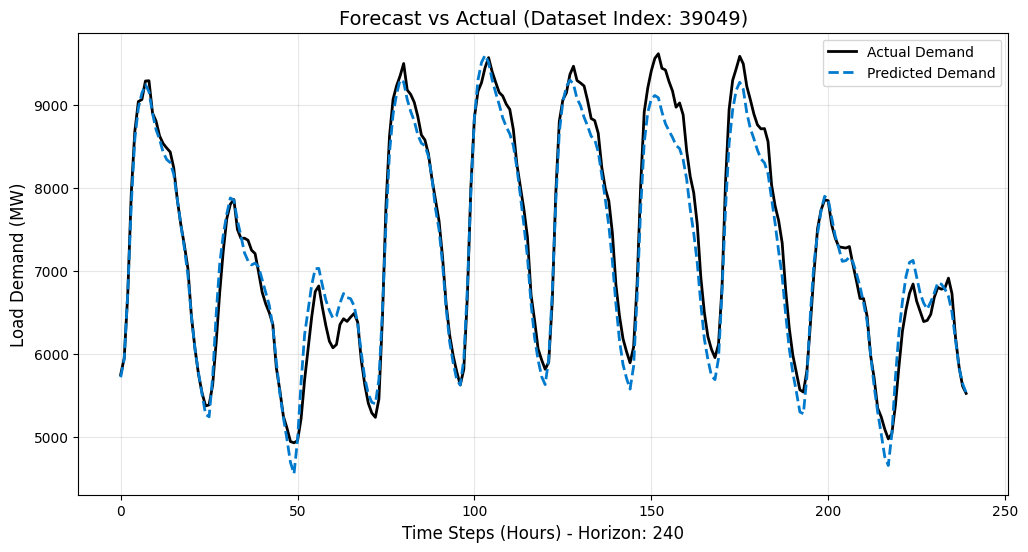

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

# --- Helper Function for Inverse Transform ---
def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    # --- 2. Re-fit the Scaler (Crucial: Fit on Train, Apply to All) ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # ---------------------------------------------------------
    # --- MODIFIED SECTION: RANDOMIZED TEST SAMPLING ---
    # ---------------------------------------------------------
    
    # Define the "Pool" of data we are allowed to test on
    # (e.g., everything after the training set)
    valid_test_start = train_split_idx
    valid_test_end = len(dataset) # The dataset class handles bounds internally usually
    
    # Create a list of all possible indices in the unseen portion
    possible_indices = np.arange(valid_test_start, valid_test_end)
    
    # How many samples do you want to test this time?
    NUM_TEST_SAMPLES = 64  
    
    print(f"\n🎲 Randomly selecting {NUM_TEST_SAMPLES} samples from the unseen data pool...")
    print(f"   Pool size: {len(possible_indices)} potential windows")

    # Pick random indices (replace=False ensures no duplicates in this batch)
    random_test_idx = np.random.choice(possible_indices, size=NUM_TEST_SAMPLES, replace=False)
    
    # Sort them just so the progress bar makes chronological sense (optional)
    random_test_idx.sort()

    # Create the Subset with these RANDOM indices
    test_subset = Subset(dataset, random_test_idx)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    
    # ---------------------------------------------------------
    # ---------------------------------------------------------

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = TR_GNN_MultiScale(**hparams).to(device) # unpacking dict for cleaner code

    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Run Inference ---
    model.eval()
    preds_list = []
    trues_list = []
    inputs_list = [] # Store inputs if you want to verify randomness

    print("Running inference...")
    with torch.no_grad():
        for X, Y in tqdm(test_loader):
            X = X.to(device)
            Y = Y.to(device)
            
            out, _ = model(X) 
            
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)

    # --- 5. Inverse Transform ---
    # CAUTION: Ensure dataset.target_idx is defined in your AT class, otherwise use 0
    target_idx = getattr(dataset, 'target_idx', 0) 
    
    preds_orig, trues_orig = inverse_transform_targets(
        preds_scaled, trues_scaled, dataset.scaler, target_idx=target_idx
    )

# --- 6. Calculate Metrics (Original Scale) ---
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(trues_orig, preds_orig)
    r2 = r2_score(trues_orig, preds_orig)
    
    # --- NEW: Calculate MAPE ---
    # We add a tiny epsilon (1e-10) to avoid division by zero if a target is 0
    epsilon = 1e-10 
    mape = np.mean(np.abs((trues_orig - preds_orig) / (trues_orig + epsilon))) * 100

    print("\n" + "="*40)
    print("      REAL-WORLD METRICS (Original Scale)")
    print("="*40)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}%")  # <--- Added MAPE here
    print(f"R²:   {r2:.4f}")
    print("="*40)

    # --- 7. Plotting a Random Sample from this Batch ---
    # Pick one random sample from the batch we just generated
    sample_idx = np.random.randint(0, len(preds_orig))
    
    plt.figure(figsize=(12, 6))
    plt.plot(trues_orig[sample_idx], label='Actual Demand', color='black', linewidth=2)
    plt.plot(preds_orig[sample_idx], label='Predicted Demand', color='#007acc', linestyle='--', linewidth=2)
    
    # Add title with the specific index used so you can track it
    actual_dataset_idx = random_test_idx[sample_idx]
    plt.title(f"Forecast vs Actual (Dataset Index: {actual_dataset_idx})", fontsize=14)
    plt.xlabel(f"Time Steps (Hours) - Horizon: {hparams['T_out']}", fontsize=12)
    plt.ylabel("Load Demand (MW)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_img_path = f"Random_Forecast_Idx_{actual_dataset_idx}.png"
    plt.savefig(save_img_path, dpi=300)
    print(f"\nPlot saved to {save_img_path}")
    plt.show()

if __name__ == "__main__":
    main()

# Integrated Gradients

Using device: cpu
Loaded dataset with 18 features (target=demand), total rows=52440
Fitting scaler on training data...

🎲 Randomly selecting 64 samples...
✅ Model weights loaded successfully.
Running inference...


100%|██████████| 1/1 [00:00<00:00, 28.57it/s]


RMSE: 405.6419 | MAPE: 3.5256%

🧠 Running Manual Integrated Gradients for Step +240...


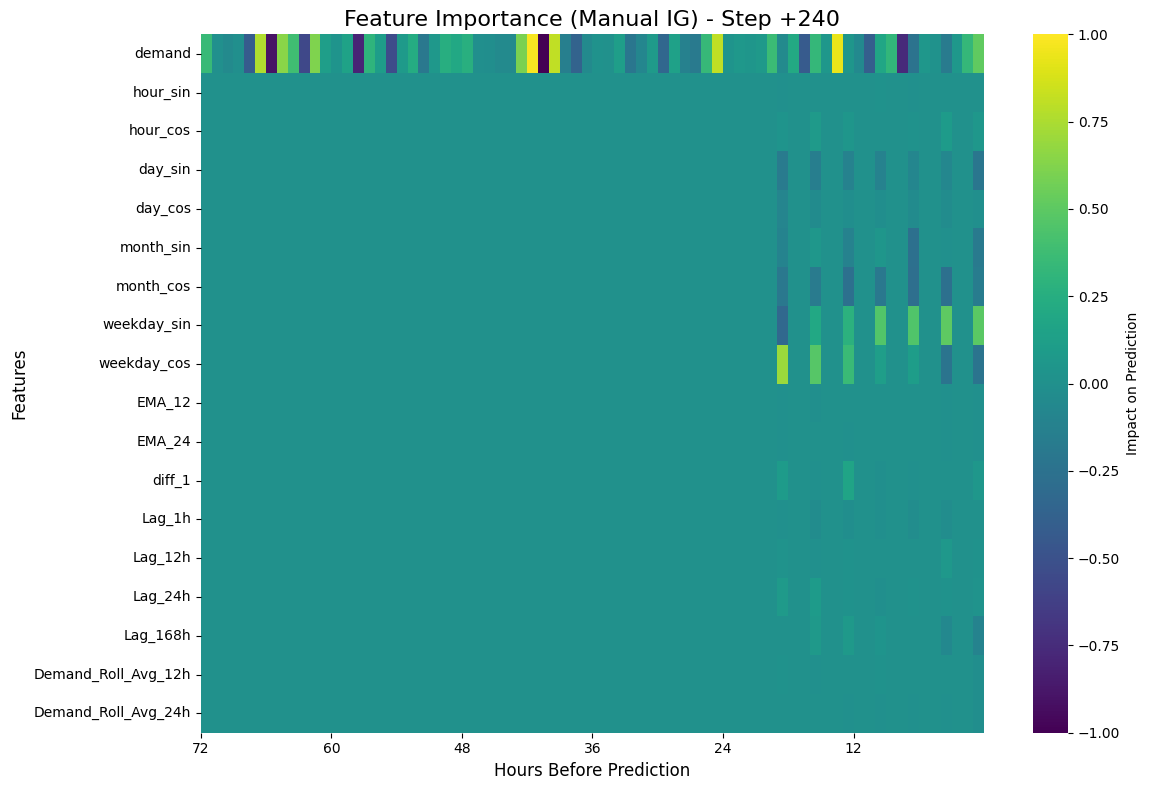

: 

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

# ---------------------------------------------------------
# --- 1. MANUAL INTEGRATED GRADIENTS (NO CAPTUM) ---
# ---------------------------------------------------------
def manual_integrated_gradients(model, input_tensor, target_step=0, steps=50, device='cuda'):
    """
    Computes Integrated Gradients manually without Captum.
    Math: (Input - Baseline) * Integral(Gradients)
    """
    model.eval()
    
    # 1. Define Baseline (Zero tensor)
    baseline = torch.zeros_like(input_tensor).to(device)
    
    # 2. Generate path inputs (Interpolation between Baseline and Input)
    # Shape: (steps+1, N, T_in)
    alphas = torch.linspace(0, 1, steps + 1).to(device)
    alphas = alphas.view(-1, 1, 1) # Reshape for broadcasting
    
    # interpolated_inputs: Batch of size (steps+1)
    # We expand input_tensor to match the batch size
    input_expanded = input_tensor.expand(steps + 1, -1, -1)
    baseline_expanded = baseline.expand(steps + 1, -1, -1)
    
    interpolated_inputs = baseline_expanded + alphas * (input_expanded - baseline_expanded)
    interpolated_inputs.requires_grad = True

    # 3. Forward Pass
    # We pass all 'steps' as a single batch for speed
    preds, _ = model(interpolated_inputs) # output: (steps+1, T_out)
    
    # 4. Select the specific time-step we want to explain
    target_score = preds[:, target_step].sum()
    
    # 5. Backward Pass (Compute Gradients)
    grads = torch.autograd.grad(
        outputs=target_score,
        inputs=interpolated_inputs,
        create_graph=False,
        retain_graph=False
    )[0] # Shape: (steps+1, N, T_in)
    
    # 6. Approximate Integral (Trapezoidal Rule or Average)
    # We average the gradients across all steps
    avg_grads = torch.mean(grads, dim=0) # Shape: (N, T_in)
    
    # 7. Calculate IG: (Input - Baseline) * Avg_Gradients
    delta = input_tensor[0] - baseline[0] # Remove batch dim 1
    ig = delta * avg_grads
    
    return ig.cpu().detach().numpy()

# ---------------------------------------------------------
# --- HELPER FUNCTIONS ---
# ---------------------------------------------------------
def inverse_transform_targets(preds_scaled, trues_scaled, scaler, target_idx=0):
    target_mean = scaler.mean_[target_idx]
    target_scale = scaler.scale_[target_idx]
    preds_orig = preds_scaled * target_scale + target_mean
    trues_orig = trues_scaled * target_scale + target_mean
    return preds_orig, trues_orig

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    # --- 2. Re-fit Scaler ---
    print("Fitting scaler on training data...")
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # --- 3. Random Sampling ---
    valid_test_start = train_split_idx
    possible_indices = np.arange(valid_test_start, len(dataset))
    
    NUM_TEST_SAMPLES = 64  
    print(f"\n🎲 Randomly selecting {NUM_TEST_SAMPLES} samples...")
    random_test_idx = np.random.choice(possible_indices, size=NUM_TEST_SAMPLES, replace=False)
    random_test_idx.sort()

    test_subset = Subset(dataset, random_test_idx)
    test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)
    
    # --- 4. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = TR_GNN_MultiScale(**hparams).to(device)

    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 5. Inference ---
    model.eval()
    preds_list = []
    trues_list = []
    xai_input_tensor = None 

    print("Running inference...")
    with torch.no_grad():
        for i, (X, Y) in enumerate(tqdm(test_loader)):
            X = X.to(device)
            Y = Y.to(device)
            
            # Save the first sample for XAI
            if i == 0:
                xai_input_tensor = X[0:1].clone() # Keep on device, requires_grad handles inside func

            out, _ = model(X) 
            preds_list.append(out.cpu().numpy())
            trues_list.append(Y.cpu().numpy())

    preds_scaled = np.concatenate(preds_list, axis=0)
    trues_scaled = np.concatenate(trues_list, axis=0)
    
    # Inverse Transform & Metrics (Skipped for brevity, same as before)
    target_idx = getattr(dataset, 'target_idx', 0) 
    preds_orig, trues_orig = inverse_transform_targets(preds_scaled, trues_scaled, dataset.scaler, target_idx)
    
    mse = mean_squared_error(trues_orig, preds_orig)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((trues_orig - preds_orig) / (trues_orig + 1e-10))) * 100
    
    print(f"\nRMSE: {rmse:.4f} | MAPE: {mape:.4f}%")

    # ---------------------------------------------------------
    # --- 6. XAI: PLOT MANUAL INTEGRATED GRADIENTS ---
    # ---------------------------------------------------------
    if xai_input_tensor is not None:
        target_step = 239 # Predict next hour
        print(f"\n🧠 Running Manual Integrated Gradients for Step +{target_step+1}...")
        
        # Call our manual function
        attr_matrix = manual_integrated_gradients(
            model, 
            xai_input_tensor, 
            target_step=target_step, 
            steps=50, 
            device=device
        )
        
        # Normalize for cleaner plot (-1 to 1)
        attr_matrix = attr_matrix / (np.max(np.abs(attr_matrix)) + 1e-9)

        # Plot
        plt.figure(figsize=(12, 8))
        sns.heatmap(
            attr_matrix, 
            yticklabels=dataset.feature_names, 
            # --- COLOR CHANGE HERE ---
            # Options: 'coolwarm' (Blue-Red), 'viridis' (Purple-Yellow), 'magma' (Black-Pink)
            cmap="viridis",  
            center=0,
            vmin = -1, vmax=1,
            cbar_kws={'label': 'Impact on Prediction'}
        )
        
        T_in = attr_matrix.shape[1]
        plt.title(f"Feature Importance (Manual IG) - Step +{target_step+1}", fontsize=16)
        
        # X-axis formatting
        plt.xticks(
            ticks=np.arange(0, T_in, 12),
            labels=np.arange(T_in, 0, -12)
        )
        plt.xlabel("Hours Before Prediction", fontsize=12)
        plt.ylabel("Features", fontsize=12)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()

Using device: cpu
Loading AT Dataset...
Loaded dataset with 18 features (target=demand), total rows=52440
✅ Model weights loaded successfully.
Analyzing Sample Index: 35021


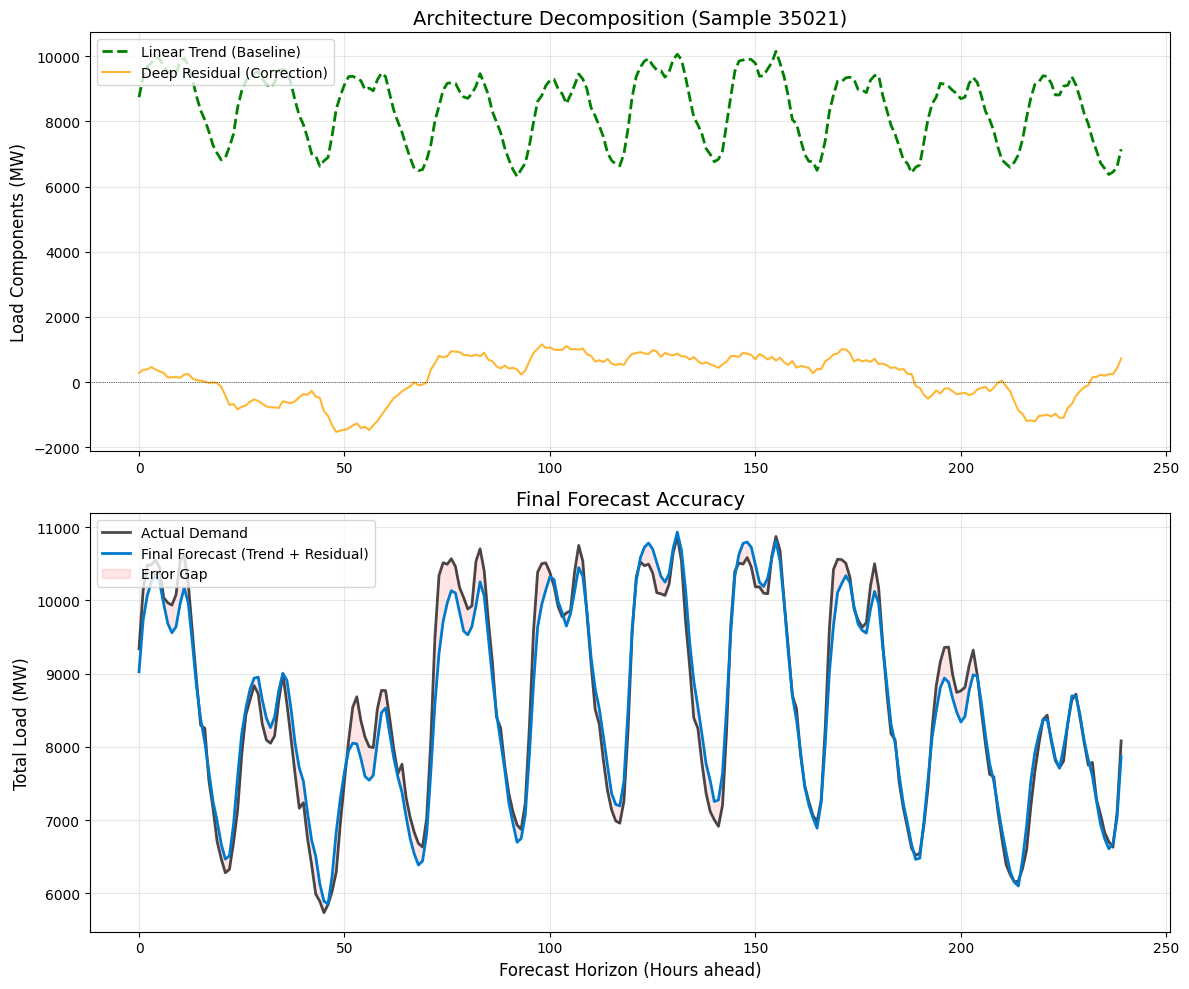

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    print("Loading AT Dataset...")
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    # --- 2. Fit Scaler (Crucial for Inverse Transform) ---
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # --- 3. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = TR_GNN_MultiScale(**hparams).to(device)
    
    # Update this path to where your best model is saved
    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 4. Select a Random Sample from Test Set ---
    valid_test_start = train_split_idx
    random_idx = np.random.randint(valid_test_start, len(dataset))
    
    print(f"Analyzing Sample Index: {random_idx}")
    input_tensor, true_target_scaled = dataset[random_idx]
    
    # Add batch dimension
    X = input_tensor.unsqueeze(0).to(device) # (1, N, T_in)
    
    # --- 5. Manual Forward Pass (Decomposition) ---
    model.eval()
    with torch.no_grad():
        # A. Run the Upstream Layers (TCN -> Graph -> GCN)
        H_temp = model.temporal_conv(X)       # (B, N, hidden)
        A = model.graph_learn(H_temp)         # (B, N, N)
        H_gcn = model.dense_gcn(H_temp, A)    # (B, N, hidden)
        
        # B. Run the "Trend" Path (Linear Baseline)
        # We assume index 0 is the target (Load)
        x_target = X[:, 0, :] 
        trend_scaled = model.forecaster.trend_linear(x_target) # (B, T_out)
        
        # C. Run the "Residual" Path (Deep Correction)
        residual_scaled = model.forecaster.residual_mlp(H_gcn) # (B, T_out)
        
        # D. Combine
        pred_scaled = trend_scaled + residual_scaled

        # Move to CPU for plotting
        trend_scaled = trend_scaled.cpu().numpy().flatten()
        residual_scaled = residual_scaled.cpu().numpy().flatten()
        pred_scaled = pred_scaled.cpu().numpy().flatten()
        true_target_scaled = true_target_scaled.cpu().numpy().flatten()

    # --- 6. Inverse Transform Logic ---
    # We need to be careful here. 
    # The Scaler equation is: Scaled = (Original - Mean) / Scale
    # So: Original = (Scaled * Scale) + Mean
    
    target_idx = getattr(dataset, 'target_idx', 0)
    mean = dataset.scaler.mean_[target_idx]
    scale = dataset.scaler.scale_[target_idx]
    
    # 1. Trend Component: Represents the BASELINE level.
    # It should include the "Mean" of the dataset.
    trend_mw = (trend_scaled * scale) + mean
    
    # 2. Residual Component: Represents the FLUCTUATION.
    # It should NOT include the mean (otherwise we add mean twice).
    residual_mw = (residual_scaled * scale)
    
    # 3. Total Prediction
    pred_mw = trend_mw + residual_mw 
    
    # 4. Actual Truth
    true_mw = (true_target_scaled * scale) + mean

    # --- 7. Plotting ---
    plt.figure(figsize=(12, 10))
    
    # Subplot 1: The Decomposition (Trend vs Residual)
    plt.subplot(2, 1, 1)
    plt.plot(trend_mw, label='Linear Trend (Baseline)', color='green', linestyle='--', linewidth=2)
    plt.plot(residual_mw, label='Deep Residual (Correction)', color='orange', alpha=0.8)
    
    # Add a zero line for the residual to show +/- fluctuations
    plt.axhline(0, color='black', linewidth=0.5, linestyle=':')
    
    plt.title(f"Architecture Decomposition (Sample {random_idx})", fontsize=14)
    plt.ylabel("Load Components (MW)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: The Final Forecast
    plt.subplot(2, 1, 2)
    plt.plot(true_mw, label='Actual Demand', color='black', linewidth=2, alpha=0.7)
    plt.plot(pred_mw, label='Final Forecast (Trend + Residual)', color='#007acc', linewidth=2)
    
    # Fill the error area
    plt.fill_between(range(len(true_mw)), true_mw, pred_mw, color='red', alpha=0.1, label='Error Gap')
    
    plt.title("Final Forecast Accuracy", fontsize=14)
    plt.xlabel(f"Forecast Horizon (Hours ahead)", fontsize=12)
    plt.ylabel("Total Load (MW)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 18 features (target=demand), total rows=52440
✅ Model weights loaded successfully.

🧠 Extracting Learned Graph Structure...


100%|██████████| 7/7 [00:00<00:00, 82.00it/s]


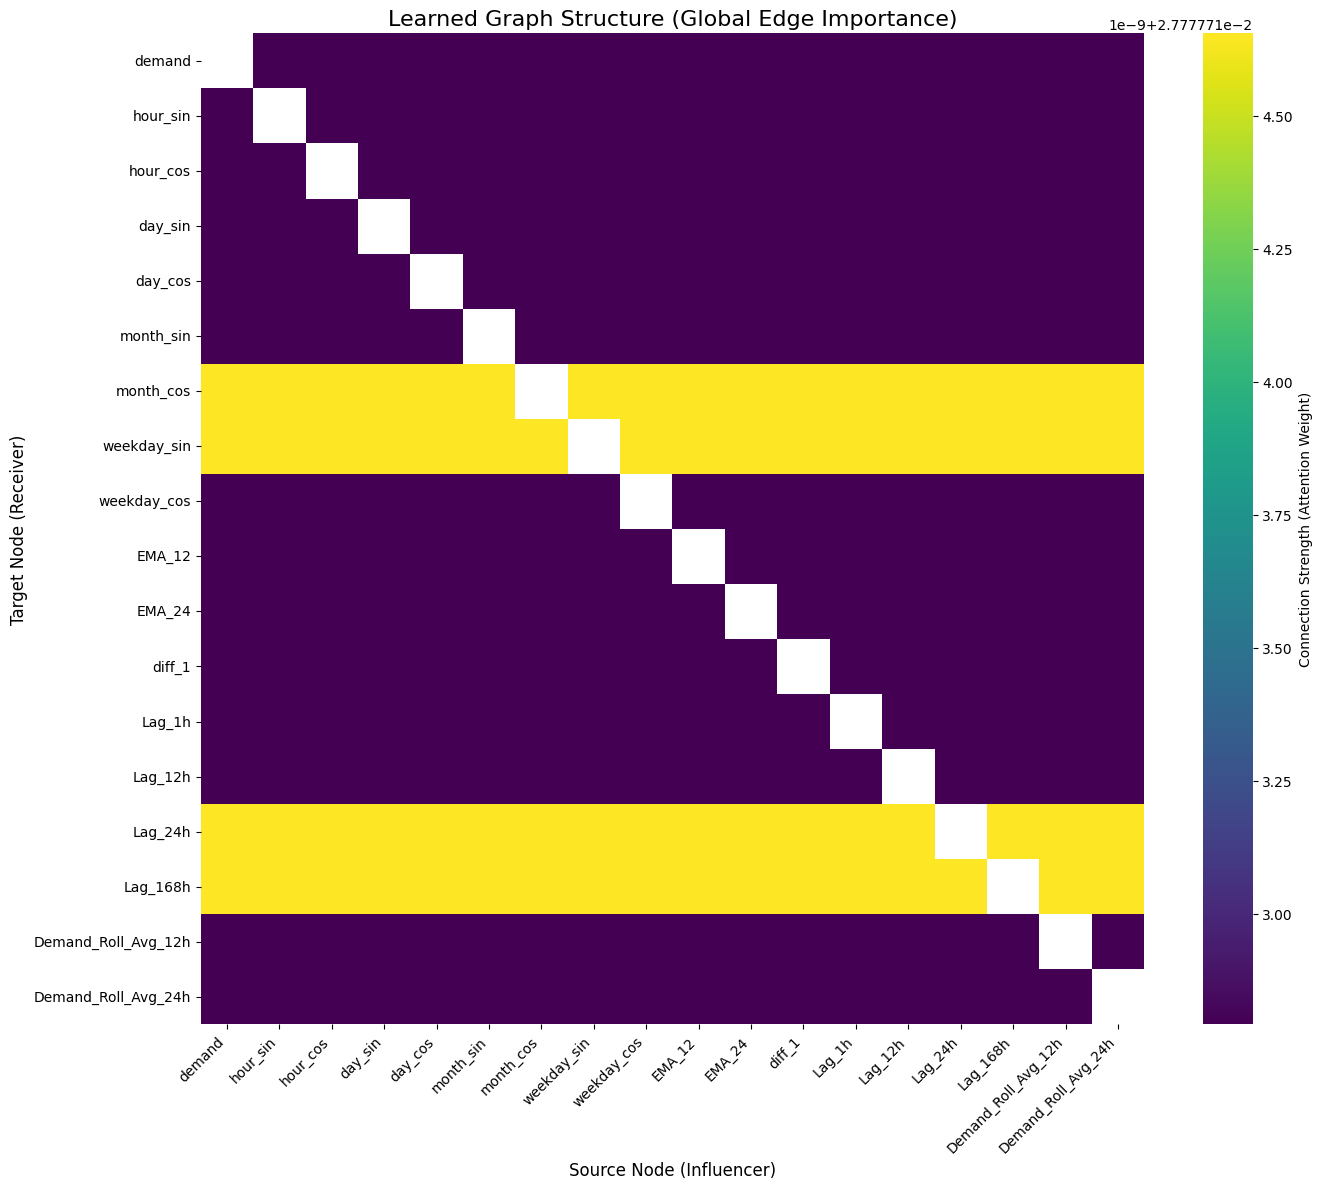


🏆 Top 10 Features Influencing Load Demand:
   demand: 0.5278
   Demand_Roll_Avg_24h: 0.0278
   Demand_Roll_Avg_12h: 0.0278
   Lag_168h: 0.0278
   Lag_12h: 0.0278
   Lag_24h: 0.0278
   diff_1: 0.0278
   EMA_24: 0.0278
   EMA_12: 0.0278
   Lag_1h: 0.0278


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import json

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # --- 1. Load Dataset ---
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72,
        T_out=240,
        lag_hours=[1,12,24,168], 
        rolling_windows=[12,24],
    )

    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # --- 2. Load Model ---
    hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
    }
    
    model = TR_GNN_MultiScale(**hparams).to(device)
    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model weights loaded successfully.")
    except FileNotFoundError:
        print(f"❌ Error: Could not find model file at {weight_path}")
        return

    # --- 3. Extract the Learned Graph (The "Explanation") ---
    print("\n🧠 Extracting Learned Graph Structure...")
    
    # We use a subset of test data to get the "Average" behavior
    # (PGExplainer usually finds a global mask, so we average A across many samples)
    test_subset = Subset(dataset, range(train_split_idx, train_split_idx + 200)) # Take 200 samples
    loader = DataLoader(test_subset, batch_size=32, shuffle=False)
    
    adj_matrices = []
    
    model.eval()
    with torch.no_grad():
        for X, Y in tqdm(loader):
            X = X.to(device)
            
            # 1. Run Temporal Conv
            H = model.temporal_conv(X)
            
            # 2. Run Graph Learning -> Get 'A'
            # A shape: (Batch, N, N)
            A = model.graph_learn(H) 
            
            adj_matrices.append(A.cpu().numpy())
            
    # Concatenate all batches
    all_adj = np.concatenate(adj_matrices, axis=0) # (200, N, N)
    
    # Compute the MEAN Adjacency Matrix (The "Global" Explanation)
    # This tells us: "On average, which nodes affect which?"
    mean_adj = np.mean(all_adj, axis=0)
    
    # --- 4. Plotting the "PGExplainer" Equivalent ---
    plt.figure(figsize=(14, 12))
    
    # Mask the diagonal (Self-loops are usually 1.0 and boring)
    mask = np.eye(mean_adj.shape[0], dtype=bool)
    
    sns.heatmap(
        mean_adj, 
        xticklabels=dataset.feature_names,
        yticklabels=dataset.feature_names,
        cmap="viridis", # 'viridis' is good for intensity (0 to 1)
        mask=mask,      # Hide the diagonal line
        annot=False,    # Turn to True if N is small (<10)
        cbar_kws={'label': 'Connection Strength (Attention Weight)'}
    )
    
    plt.title("Learned Graph Structure (Global Edge Importance)", fontsize=16)
    plt.xlabel("Source Node (Influencer)", fontsize=12)
    plt.ylabel("Target Node (Receiver)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # --- 5. Drill Down: What drives the Load? ---
    # We extract just the row corresponding to the Target (Load)
    # This answers: "Which features does the Load Node pay attention to?"
    target_idx = getattr(dataset, 'target_idx', 0) 
    load_row = mean_adj[target_idx, :]
    
    # Sort them to find top influencers
    indices = np.argsort(load_row)[::-1] # Descending
    top_indices = indices[:10] # Top 10
    
    print("\n🏆 Top 10 Features Influencing Load Demand:")
    for i in top_indices:
        name = dataset.feature_names[i]
        score = load_row[i]
        print(f"   {name}: {score:.4f}")

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 18 features (target=demand), total rows=52440
✅ Model loaded.
🚀 Training PGExplainer for 15 epochs...
   Epoch 1/15 | Loss: 36.4650
   Epoch 2/15 | Loss: 7.5837
   Epoch 3/15 | Loss: 2.1013
   Epoch 4/15 | Loss: 0.9315
   Epoch 5/15 | Loss: 0.5556
   Epoch 6/15 | Loss: 0.4248
   Epoch 7/15 | Loss: 0.4440
   Epoch 8/15 | Loss: 0.3212
   Epoch 9/15 | Loss: 0.3281
   Epoch 10/15 | Loss: 0.3613
   Epoch 11/15 | Loss: 0.3040
   Epoch 12/15 | Loss: 0.3185
   Epoch 13/15 | Loss: 0.2927
   Epoch 14/15 | Loss: 0.2906
   Epoch 15/15 | Loss: 0.2737

🧠 Generating Explanations...


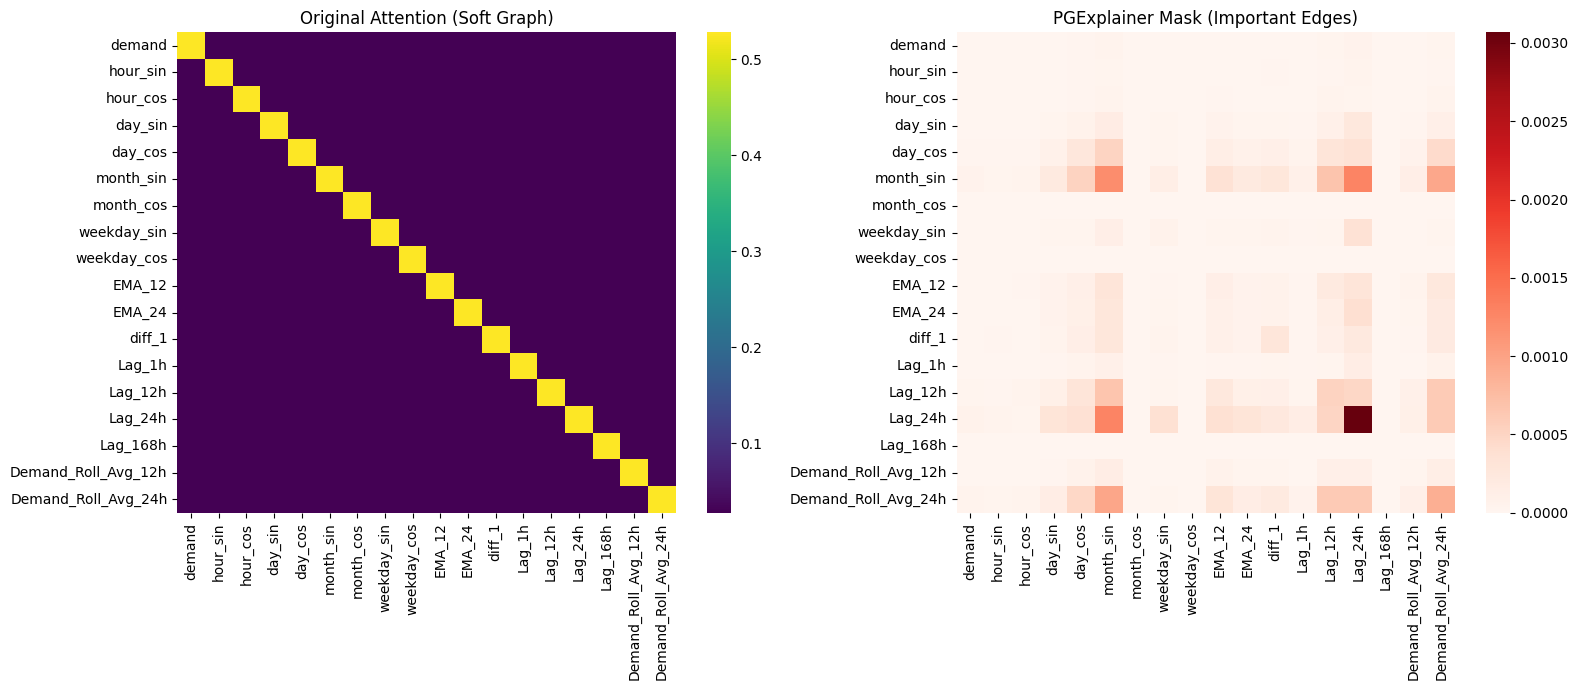


✅ Interpretation:
The LEFT plot is what your model 'thinks' (Attention weights).
The RIGHT plot is what PGExplainer 'selected' as strictly necessary.
If an edge is bright Red in the right plot, removing it would destroy the forecast.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

# ---------------------------------------------------------
# --- 1. DEFINE THE PG-EXPLAINER MODULE ---
# ---------------------------------------------------------
class DensePGExplainer(nn.Module):
    """
    Adapts the PGExplainer algorithm for Dense, Temporal Graphs.
    Trains a mask generator to select important edges in the NxN adjacency matrix.
    """
    def __init__(self, model, hidden_dim=64):
        super().__init__()
        self.model = model
        self.model.eval() # The original model must be frozen
        
        # The Explainer Network
        # Input: 2 * hidden_dim (concatenation of node pair embeddings)
        # Output: 1 (The probability of keeping the edge)
        self.explainer_net = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def _create_explainer_input(self, H):
        """
        Constructs pair-wise embeddings for the dense graph.
        H: (Batch, N, D)
        Returns: (Batch, N, N, 2*D)
        """
        B, N, D = H.shape
        # Repeat H to form pairs
        # H_i: (B, N, 1, D) -> repeated to (B, N, N, D)
        # H_j: (B, 1, N, D) -> repeated to (B, N, N, D)
        H_i = H.unsqueeze(2).repeat(1, 1, N, 1)
        H_j = H.unsqueeze(1).repeat(1, N, 1, 1)
        
        # Concatenate to get (h_i || h_j) for every pair
        pair_embeds = torch.cat([H_i, H_j], dim=-1)
        return pair_embeds

    def forward(self, X, temperature=0.1):
        """
        Forward pass that generates a mask and runs the model with it.
        """
        # 1. Get original embeddings from the frozen model
        with torch.no_grad():
            H_temp = self.model.temporal_conv(X) # (B, N, D)
            A_orig = self.model.graph_learn(H_temp) # (B, N, N)
        
        # 2. Predict the Mask using the Explainer Network
        pair_embeds = self._create_explainer_input(H_temp) # (B, N, N, 2D)
        
        # Predict logits for every edge
        mask_logits = self.explainer_net(pair_embeds).squeeze(-1) # (B, N, N)
        
        # 3. Sampling (Reparameterization Trick)
        # We use Concrete Distribution (Gumbel-Sigmoid) to make it differentiable
        # During training, we sample. During inference, we just use sigmoid.
        if self.training:
            eps = (torch.rand_like(mask_logits) + 1e-8).log()
            eps = (torch.rand_like(mask_logits) + 1e-8).log() - eps
            mask = torch.sigmoid((mask_logits + eps) / temperature)
        else:
            mask = torch.sigmoid(mask_logits)
            
        # 4. Apply Mask to Original Graph
        # We perform element-wise multiplication
        A_masked = A_orig * mask
        
        # 5. Run the rest of the model with the MASKED graph
        # Note: We must allow gradients to flow back to the Mask, but NOT the model weights
        # So we detach model weights implicitly by not adding them to the optimizer later.
        H_gcn = self.model.dense_gcn(H_temp, A_masked)
        Y_hat_masked = self.model.forecaster(X, H_gcn)
        
        return Y_hat_masked, mask, A_orig

def train_pg_explainer(explainer, dataset, device, epochs=10, lr=0.005, lambda_size=0.05):
    """
    Trains the explainer to minimize prediction error while maximizing sparsity.
    """
    optimizer = optim.Adam(explainer.explainer_net.parameters(), lr=lr)
    
    # We use a subset for training the explainer (it learns fast)
    # Train on 200 samples
    subset_idx = range(len(dataset)-300, len(dataset)-100)
    loader = DataLoader(Subset(dataset, subset_idx), batch_size=32, shuffle=True)
    
    print(f"🚀 Training PGExplainer for {epochs} epochs...")
    
    for epoch in range(epochs):
        total_loss = 0
        
        for X, Y in loader:
            X = X.to(device)
            Y = Y.to(device)
            
            # 1. Get Original Prediction (Target)
            with torch.no_grad():
                Y_orig, _ = explainer.model(X)
            
            # 2. Get Masked Prediction
            explainer.train()
            Y_masked, mask, _ = explainer(X)
            
            # 3. Calculate Loss
            # Prediction Fidelity Loss: Masked pred should match Original pred
            loss_pred = nn.MSELoss()(Y_masked, Y_orig)
            
            # Size Loss: Mask should be sparse (sum of mask -> 0)
            loss_size = torch.mean(torch.sum(mask, dim=[-1, -2]))
            
            # Entropy Loss (Optional): Encourage binary (0 or 1) masks
            # loss_ent = -mask * torch.log(mask + 1e-8) - (1 - mask) * torch.log(1 - mask + 1e-8)
            # loss_ent = torch.mean(loss_ent)

            # Total Loss
            loss = loss_pred + lambda_size * loss_size
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        print(f"   Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")
        
    return explainer

# ---------------------------------------------------------
# --- 2. MAIN SCRIPT ---
# ---------------------------------------------------------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load Dataset
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72, T_out=240, lag_hours=[1,12,24,168], rolling_windows=[12,24],
    )
    
    # Scaler
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    dataset.scaler = scaler 

    # Load Model
    hparams = {
        "N": dataset.N, "T_in": 72, "T_out": 240, "d": 32,
        "hidden_dim": 64, "GCN_Layer": 5, "dropout_forecast": 0.1,
        "dropout_gcn": 0.2, "dropout_temporal": 0.2,
    }
    model = TR_GNN_MultiScale(**hparams).to(device)
    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model loaded.")
    except:
        print("❌ Model not found.")
        return

    # --- Initialize & Train PGExplainer ---
    pg_explainer = DensePGExplainer(model, hidden_dim=64).to(device)
    
    # Train it! (Learns which edges are important)
    pg_explainer = train_pg_explainer(pg_explainer, dataset, device, epochs=15)
    
    # --- Inference & Visualization ---
    print("\n🧠 Generating Explanations...")
    pg_explainer.eval()
    
    # Grab a batch to explain
    test_loader = DataLoader(Subset(dataset, range(len(dataset)-50, len(dataset))), batch_size=32)
    X_test, _ = next(iter(test_loader))
    X_test = X_test.to(device)
    
    with torch.no_grad():
        _, mask, A_orig = pg_explainer(X_test)
        
        # Average the learned mask across the batch
        # This gives us the "Global Importance" learned by the explainer
        avg_mask = mask.mean(dim=0).cpu().numpy()
        avg_orig = A_orig.mean(dim=0).cpu().numpy()
        
    # --- Plotting ---
    plt.figure(figsize=(16, 7))
    
    # Plot 1: Original Learned Graph (Attention)
    plt.subplot(1, 2, 1)
    sns.heatmap(avg_orig, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="viridis")
    plt.title("Original Attention (Soft Graph)")
    
    # Plot 2: PGExplainer Result (Hard Mask)
    plt.subplot(1, 2, 2)
    sns.heatmap(avg_mask, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="Reds")
    plt.title("PGExplainer Mask (Important Edges)")
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Interpretation:")
    print("The LEFT plot is what your model 'thinks' (Attention weights).")
    print("The RIGHT plot is what PGExplainer 'selected' as strictly necessary.")
    print("If an edge is bright Red in the right plot, removing it would destroy the forecast.")

if __name__ == "__main__":
    main()

Using device: cpu
Loaded dataset with 18 features (target=demand), total rows=52440
✅ Model loaded.

🧠 Explaining Sample 49500 (DenseGNNExplainer)...


Optimizing Mask: 100%|██████████| 200/200 [00:01<00:00, 144.72it/s, Loss=0.109, Sparsity=0.137]


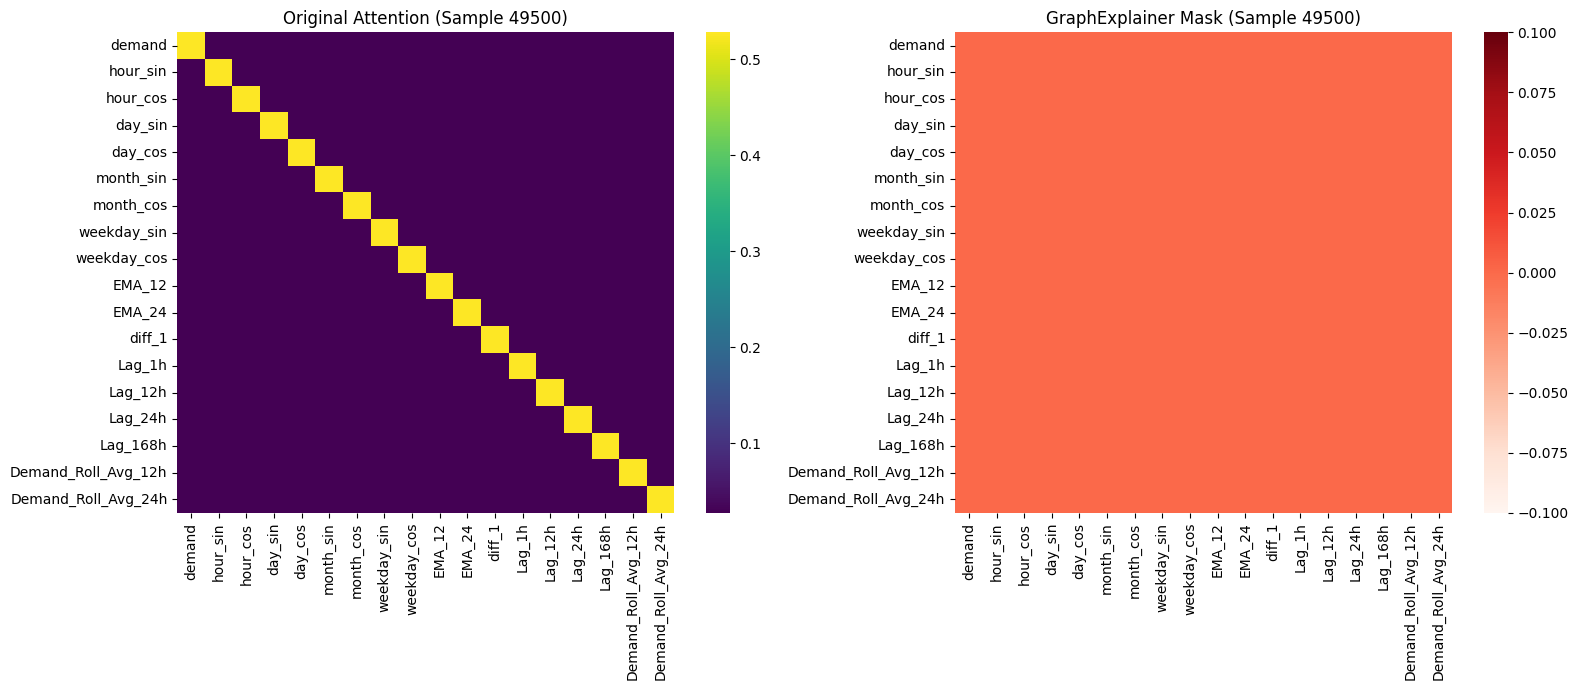


✅ Interpretation:
- Left: The raw 'noisy' graph the model generated internally.
- Right: The 'Explanation' - The minimal edges strictly needed to make this specific prediction.
- This tells you exactly which node interactions drove THIS specific forecast.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# Import your custom classes
from dataset_classes import AT
from models_with_temporal_graph import TR_GNN_MultiScale

# ---------------------------------------------------------
# --- 1. DENSE GNN-EXPLAINER (Instance Optimizer) ---
# ---------------------------------------------------------
class DenseGNNExplainer(nn.Module):
    """
    Optimizes a soft mask for a SINGLE input instance.
    Goal: Find a sparse mask M such that Prediction(A * M) is close to Prediction(A).
    """
    def __init__(self, model, X_sample, device):
        super().__init__()
        self.model = model
        self.model.eval()
        self.device = device
        
        # 1. Run model once to get static features and original adjacency
        with torch.no_grad():
            self.H_temp = model.temporal_conv(X_sample) # (1, N, D)
            self.A_orig = model.graph_learn(self.H_temp) # (1, N, N)
            self.target_pred, _ = model(X_sample)       # Original prediction
            
        # 2. Initialize the Mask (Learnable Parameter)
        # We start with random noise or all ones
        N = self.A_orig.shape[1]
        self.mask_logits = nn.Parameter(torch.randn(1, N, N, device=device) * 0.1)
        
    def forward(self):
        # Sigmoid to map logits to [0, 1]
        mask = torch.sigmoid(self.mask_logits)
        
        # Apply mask to the original static graph
        A_masked = self.A_orig * mask
        
        # Run GCN + Forecaster part only
        H_gcn = self.model.dense_gcn(self.H_temp, A_masked)
        
        # Pass Raw X (for trend) and H_gcn (for residual)
        # We need the original X for the 'Trend' linear part
        # But we can cheat and use the pre-computed H_temp context if we restructure,
        # OR just call the forecaster sub-modules directly.
        
        # Let's call the forecaster properly.
        # The forecaster needs the original X for the trend path.
        # We can't easily pass 'X' here without storing it.
        # Let's modify the flow slightly or assume the user passes it.
        pass 
        
    def get_masked_pred(self, X_raw):
        mask = torch.sigmoid(self.mask_logits)
        A_masked = self.A_orig * mask
        H_gcn = self.model.dense_gcn(self.H_temp, A_masked)
        return self.model.forecaster(X_raw, H_gcn), mask

def explain_instance(model, dataset, sample_idx, device, epochs=200, lr=0.01):
    print(f"\n🧠 Explaining Sample {sample_idx} (DenseGNNExplainer)...")
    
    # Get Data
    X_sample, _ = dataset[sample_idx]
    X_sample = X_sample.unsqueeze(0).to(device) # (1, N, T_in)
    
    # Initialize Explainer
    explainer = DenseGNNExplainer(model, X_sample, device).to(device)
    optimizer = optim.Adam([explainer.mask_logits], lr=lr)
    
    # Optimization Loop
    pbar = tqdm(range(epochs), desc="Optimizing Mask")
    for epoch in pbar:
        optimizer.zero_grad()
        
        # Get prediction with current mask
        pred_masked, mask = explainer.get_masked_pred(X_sample)
        
        # Loss 1: Fidelity (Prediction should match original)
        loss_pred = nn.MSELoss()(pred_masked, explainer.target_pred)
        
        # Loss 2: Sparsity (Mask should be mostly zeros)
        loss_size = torch.mean(mask)
        
        # Loss 3: Entropy (Mask should be binary 0 or 1, not 0.5)
        loss_ent = -mask * torch.log(mask + 1e-8) - (1 - mask) * torch.log(1 - mask + 1e-8)
        loss_ent = torch.mean(loss_ent)
        
        # Weighted Sum
        loss = loss_pred + 0.5 * loss_size + 0.1 * loss_ent
        
        loss.backward()
        optimizer.step()
        
        pbar.set_postfix({'Loss': loss.item(), 'Sparsity': loss_size.item()})
        
    # Extract Final Mask
    final_mask = torch.sigmoid(explainer.mask_logits).detach().cpu().numpy()[0]
    original_adj = explainer.A_orig.detach().cpu().numpy()[0]
    
    return final_mask, original_adj

# ---------------------------------------------------------
# --- 2. MAIN SCRIPT ---
# ---------------------------------------------------------
def main():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load Dataset
    dataset = AT(
        csv_path="GLFN-TC/Datasets/AT-Dataset/AT Dataset.csv",
        T_in=72, T_out=240, lag_hours=[1,12,24,168], rolling_windows=[12,24],
    )
    
    # Scaler
    total_len = len(dataset.df_numeric)
    train_split_idx = int(0.6 * total_len)
    scaler = StandardScaler()
    scaler.fit(dataset.df_numeric.iloc[:train_split_idx].values.astype(np.float32))
    dataset.apply_scaler(scaler)
    
    # Load Model
    hparams = {
        "N": dataset.N, "T_in": 72, "T_out": 240, "d": 32,
        "hidden_dim": 64, "GCN_Layer": 5, "dropout_forecast": 0.1,
        "dropout_gcn": 0.2, "dropout_temporal": 0.2,
    }
    model = TR_GNN_MultiScale(**hparams).to(device)
    weight_path = "Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth"
    try:
        model.load_state_dict(torch.load(weight_path, map_location=device))
        print("✅ Model loaded.")
    except:
        return

    # --- Run GraphExplainer on a Random Test Sample ---
    # Pick a random sample from the test set
    rand_idx = np.random.randint(train_split_idx, len(dataset))
    
    mask, orig_adj = explain_instance(model, dataset, rand_idx, device)
    
    # Threshold the mask for cleaner visualization
    mask_thresholded = np.where(mask > 0.5, mask, 0)
    
    # --- Visualization ---
    plt.figure(figsize=(16, 7))
    
    # Plot 1: Original Learned Graph (Attention)
    plt.subplot(1, 2, 1)
    sns.heatmap(orig_adj, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="viridis")
    plt.title(f"Original Attention (Sample {rand_idx})")
    
    # Plot 2: Optimized Explanation Mask
    plt.subplot(1, 2, 2)
    sns.heatmap(mask_thresholded, xticklabels=dataset.feature_names, yticklabels=dataset.feature_names, cmap="Reds")
    plt.title(f"GraphExplainer Mask (Sample {rand_idx})")
    
    plt.tight_layout()
    plt.show()
    
    print("\n✅ Interpretation:")
    print("- Left: The raw 'noisy' graph the model generated internally.")
    print("- Right: The 'Explanation' - The minimal edges strictly needed to make this specific prediction.")
    print("- This tells you exactly which node interactions drove THIS specific forecast.")

if __name__ == "__main__":
    main()

In [ ]:
import torch
from models_with_temporal_graph import TR_GNN_MultiScale  # Import your model class
from dataset_classes import AT

dataset = AT(
    csv_path="GLFN-TC\Datasets\AT-Dataset\AT Dataset.csv",
    T_in=72,
    T_out=240,
    lag_hours=[1,12,24,168], 
    rolling_windows=[12,24],
)

hparams = {
        "N": dataset.N,
        "T_in": 72,
        "T_out": 240,
        "d": 32,
        "hidden_dim": 64,
        "GCN_Layer": 5,
        "dropout_forecast": 0.1,
        "dropout_gcn": 0.2,
        "dropout_temporal": 0.2,
        "lr": 1e-4,
        "scheduler_patience": 3,
        "batch_size": 64, # Updated from 16
        "epochs": 100,
        "weight_decay": 1e-4, # Added this new hyperparameter
    }
model = TR_GNN_MultiScale(
    N=hparams["N"],
    T_in=hparams["T_in"],
    T_out=hparams["T_out"],
    d=hparams["d"],
    hidden_dim=hparams["hidden_dim"],
    GCN_Layer=hparams["GCN_Layer"],
    dropout_gcn=hparams["dropout_gcn"],
    dropout_temporal=hparams["dropout_temporal"],
)

# Load weights
checkpoint = torch.load("Final_Run/AT_TR_GNN_MultiScale_Temporal_Graph_Learning_best_model.pth", map_location='cpu')
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {total_params - trainable_params:,}")
print(f"Model Size: {total_params * 4 / (1024**2):.2f} MB (float32)")

Loaded dataset with 18 features (target=demand), total rows=52440
Total Parameters: 769,696
Trainable Parameters: 769,696
Non-trainable Parameters: 0
Model Size: 2.94 MB (float32)
